In [19]:
from model_ranking import load_h5, get_unique_colourmap, get_roi_slice
import matplotlib.pyplot as plt
import numpy as np

In [20]:
PNAS_gt_path = "/scratch/talks/data/PNAS/test/36hrs_plant18_trim-acylYFP.h5"
gt = load_h5(PNAS_gt_path, "label")
raw = load_h5(PNAS_gt_path, "raw")

In [21]:
pred_path ="/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/PNAS_to_PNAS_gap/consistency/P_full/p_model_UNet1/norm_50_950/none/predictions/36hrs_plant18_trim-acylYFP_predictions.h5"
IN_pred = load_h5(pred_path, "segmentation")
pred = load_h5(pred_path, "predictions")
patch_index = load_h5(pred_path, "patch_index")
MAP_scores = load_h5(pred_path, "MAP_05_095")

In [22]:
gt.shape

(189, 512, 512)

In [23]:
MAP_scores[:33]

array([0.70349765, 0.661429  , 0.6129447 , 0.6737482 , 0.7781665 ,
       0.6727072 , 0.6720059 , 0.70514816, 0.78696066, 0.746599  ,
       0.73584807, 0.69978255, 0.77050304, 0.6841933 , 0.7236784 ,
       0.7536108 , 0.7945286 , 0.75646037, 0.7251442 , 0.67543024,
       0.7280872 , 0.7502398 , 0.6492012 , 0.6557522 , 0.6668047 ,
       0.7435938 , 0.6850639 , 0.68952495, 0.687417  , 0.64305514,
       0.71307784, 0.6579344 , 0.70880485], dtype=float32)

In [24]:
print(IN_pred.shape)

(756, 1, 1, 256, 256)


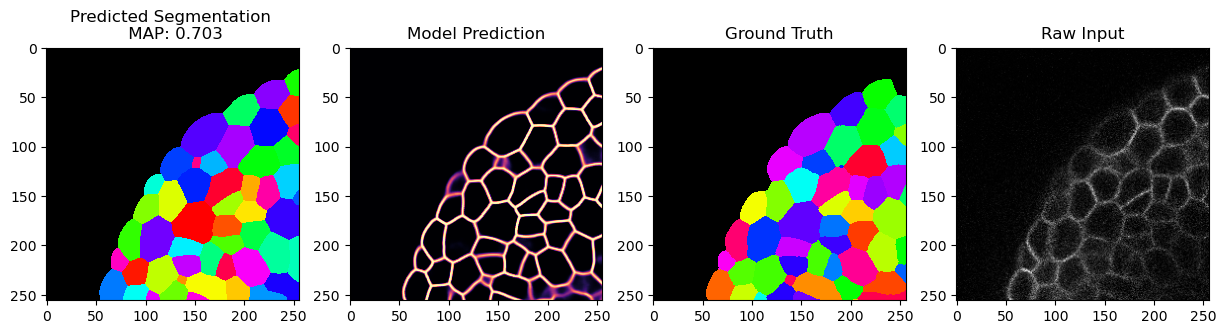

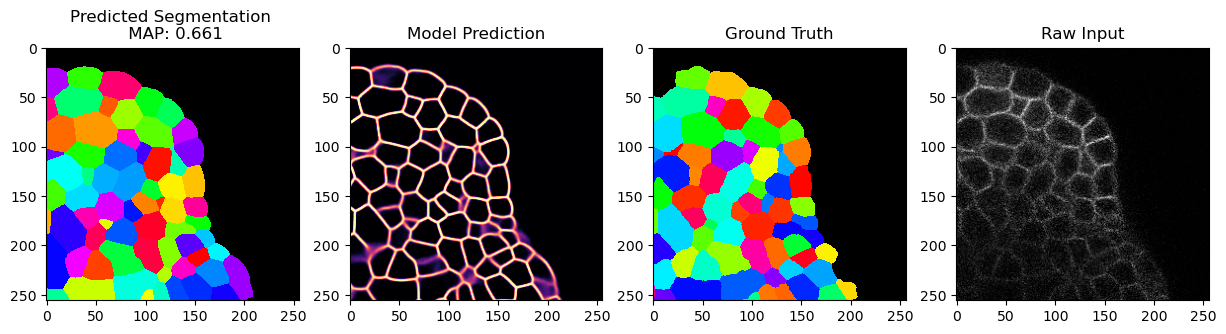

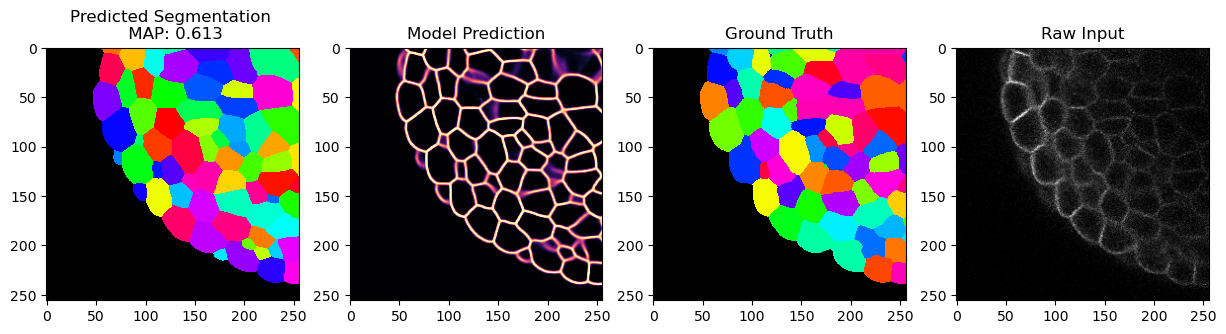

In [25]:
for i in range(3):
    patch_roi = get_roi_slice(patch_index[i])
    _, axs = plt.subplots(1, 4, figsize=(15, 5))
    axs[0].imshow(IN_pred[i].squeeze(), cmap=get_unique_colourmap(IN_pred[i]), interpolation='nearest')
    axs[0].set_title(f"Predicted Segmentation \n MAP: {MAP_scores[i]:.3f}")
    axs[1].imshow(pred[i].squeeze(), cmap="magma")
    axs[1].set_title(f"Model Prediction")
    axs[2].imshow(gt[patch_roi].squeeze(), cmap=get_unique_colourmap(gt[i]), interpolation='nearest')
    axs[2].set_title(f"Ground Truth")
    axs[3].imshow(raw[patch_roi].squeeze(), cmap="gray")
    axs[3].set_title(f"Raw Input")
    plt.show()